### 목표설정
- 선형회귀모델을 활용해서 보스턴 주택가격을 예측해봅시다.
- 특성 확장을 해서 성능을 개선시켜 봅시다.
- 규제 모델을 활용해봅시다.

In [9]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [10]:
# 데이터 불러오기
data = pd.read_csv('./data/house_price.csv')
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,CAT.MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,0
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,0
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,0
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0,0


In [11]:
# 결측치 확인하기
data.info()

# -> 결측치 없음
# -> 컬럼 정보 확인 필요

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CRIM      506 non-null    float64
 1   ZN        506 non-null    float64
 2   INDUS     506 non-null    float64
 3   CHAS      506 non-null    int64  
 4   NOX       506 non-null    float64
 5   RM        506 non-null    float64
 6   AGE       506 non-null    float64
 7   DIS       506 non-null    float64
 8   RAD       506 non-null    int64  
 9   TAX       506 non-null    int64  
 10  PTRATIO   506 non-null    float64
 11  B         506 non-null    float64
 12  LSTAT     506 non-null    float64
 13  MEDV      506 non-null    float64
 14  CAT.MEDV  506 non-null    int64  
dtypes: float64(11), int64(4)
memory usage: 59.4 KB


In [12]:
# 컬럼 추출하기
data.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV', 'CAT.MEDV'],
      dtype='object')

**[독립변수 / 특성값 / 문제데이터]**
- 'CRIM' : 구역별 1인당 범죄율 - 범죄율이 높으면 집값이 낮아지는 경향
- 'ZN' : 25,000 평방피트를 초과하는 거주지역의 비율 - 대형 주택단지 비중
- 'INDUS' : 구역별 비소매 상업지역 점유 비율 - 공업/상업 시설 밀집도 (주변 인프라)
- 'CHAS' : 찰스강과 인접해있는지(0 - 인접X / 1 - 인접) - 조망권/입지 가치
- 'NOX' : 대기 중 일산화질소 농도 - 환경 오염 정도
- 'RM' : 주택 1가구당 평균 방의 갯수
- 'AGE' : 1940년 이전 건축된 소유주택의 비율 - 건물의 노후도
- 'DIS' : 보스턴 직업센터까지의 가중 거리 - 도심 접근성
- 'RAD' : 방사형 고속도로 접근성 지수 - 교통 편의성
- 'TAX' : 10,000달러 당 재산세의 비율 - 세금 부담 정도
- 'PTRATIO' : 구역별 학생-교사 비율 - 교육환경(낮을수록 학급당 학생수 적다)
- 'B' : 흑인의 비율 - 치안
- 'LSTAT' : 하위계층의 비율 - 소득,직업,교육수준 ... 

**[종속변수 / 예측값 / 정답데이터]**
- 'MEDV' : 본인 소유 주택가격의 중앙값(단위는 $1000)
- 'CAT.MEDV' : 30,000달러 이상이면 1 / 미만이면 0 -> 필요없는 컬럼(우리는 회귀분석 진행)
  -> 삭제예장

In [13]:
# CAT.MEDV 컬럼 삭제
data = data.drop('CAT.MEDV', axis = 1)
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [15]:
# 기술 통계 살펴보기

# count - 데이터 갯수
# mean - 평균
# std - 표준편차
# min - 최솟값
# 50% - 중위값(중앙값)
# max - 최댓값
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


**[4분위수]**
- 25% 1사분위 / 50% 2사분위&중앙값 / 75% 3사분위 / 100% 4사분위
- 데이터의 분포를 확인 할 때 사용 / 이상치 탐색시 사용 
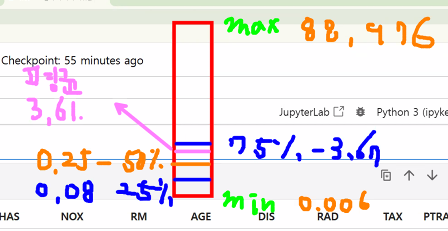
- 범죄율(CRIM)에 대한 데이터는 모든 값이 최솟값에 쏠려 있다. -> 범죄율이 낮은 쪽으로 몰려있다.

In [17]:
# 상관계수 살펴보기
# 상관계수 : 두 변수 사이에 관계가 얼마나 되는지 강도와 뱡향을 수치화 한 지표
# 범위 : -1 ~ 1

# 상관계수
# 0.7 ~ 1.0 : 강한 상관관계
# 0.3 ~ 0.7 : 뚜렷한 상관관계
# 0.1 ~ 0.3 : 약한 상관관계
# 0.0 ~ 0.1 : 관계거의 없음
# + : 양의 상관관계, 하나의 변수가 증가하면 다른 변수도 일정한 비율로 증가
# - : 음의 상관관계, 하나의 변수가 증가하면 다른 변수도 일정한 비율로 감소

data.corr()
# 인덱스와 컬럼의 이름과 순서가 동일 
# 대각선 값이 1인것은 볼 필요 없음

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


In [18]:
# 1. 상관계수를 보고싶은 컬럼을 추출하기
data.corr()['CRIM']

CRIM       1.000000
ZN        -0.200469
INDUS      0.406583
CHAS      -0.055892
NOX        0.420972
RM        -0.219247
AGE        0.352734
DIS       -0.379670
RAD        0.625505
TAX        0.582764
PTRATIO    0.289946
B         -0.385064
LSTAT      0.455621
MEDV      -0.388305
Name: CRIM, dtype: float64

In [19]:
# 2. 상관계수의 절대값을 확인하기
data.corr()['CRIM'].abs()

CRIM       1.000000
ZN         0.200469
INDUS      0.406583
CHAS       0.055892
NOX        0.420972
RM         0.219247
AGE        0.352734
DIS        0.379670
RAD        0.625505
TAX        0.582764
PTRATIO    0.289946
B          0.385064
LSTAT      0.455621
MEDV       0.388305
Name: CRIM, dtype: float64

In [20]:
# 3. 내림차순 정렬진행
data.corr()['CRIM'].abs().sort_values(ascending = False)
# 'RAD'컬럼이 상관계수 가장 크다.

CRIM       1.000000
RAD        0.625505
TAX        0.582764
LSTAT      0.455621
NOX        0.420972
INDUS      0.406583
MEDV       0.388305
B          0.385064
DIS        0.379670
AGE        0.352734
PTRATIO    0.289946
RM         0.219247
ZN         0.200469
CHAS       0.055892
Name: CRIM, dtype: float64

In [21]:
# 4. 기호판별하기
# 양의 상관관계 - CRIM이 증가하면 일정 비율로 RAD도 증가하는 관계다.

<Axes: >

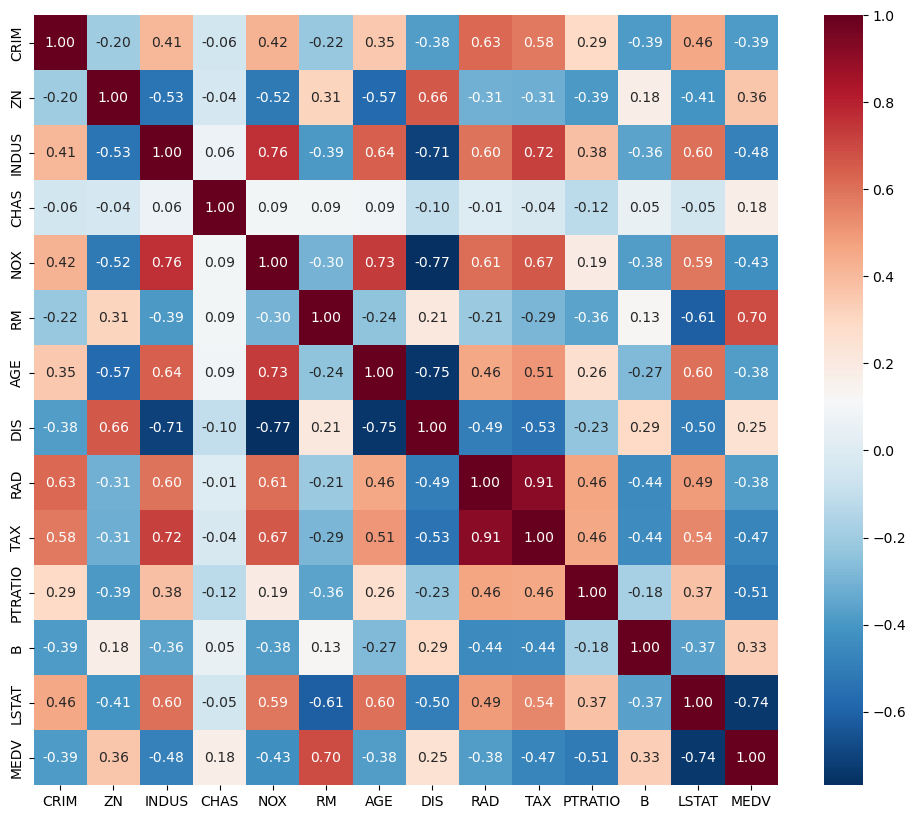

In [23]:
# 5. 시각화 진행하기
import seaborn as sns
plt.figure(figsize = (12,10)) # 그래프 사이즈 조절

sns.heatmap(
    data.corr(), # 히트맵을 그릴 데이터프레임
    annot = True, # 히트맵 내부 수치값 표시
    fmt = ".2f", # 소수점 자리 지정
    cmap = 'RdBu_r' # 양수 - 빨간색 / 음수 - 파란색, _r은 reverse의 약자
)

In [ ]:
# 히트맵으로 시각화 하는 이유
# 색깔의 진하기에 따라 약한 상관관계인지 강한 상관관계인지 파악
# 색깔로 양의 상관관계 / 음의 상관관계 파악

### 20260305
- 데이터분할 -> 모델학습 -> 평가 -> 특성확장 -> 규제모델